In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [4]:
df = pd.read_csv('household_power_consumption.txt', sep=';', na_values=['?'], low_memory=False)

df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time']).set_index('DateTime')

print(df.shape)
df.head()

(2075259, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
# quick look at data types and how many values are missing per column
df.info()
print()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [6]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


About 1.25% of rows are missing across the board (the docs mention a gap around late April 2007
among others), which lines up with the ~26k missing values seen above.

In [7]:
power = df.loc['2006-12-01':'2009-11-30'].copy()
print('Full dataset :', df.shape)
print('Subset       :', power.shape)
print(power.index.min(), '->', power.index.max())

Full dataset : (2075259, 7)
Subset       : (1555596, 7)
2006-12-16 17:24:00 -> 2009-11-30 23:59:00


In [8]:
# drop the missing readings in the subset so the plots below aren't disrupted by gaps
power = power.dropna()
print('After dropping missing values:', power.shape)

After dropping missing values: (1547248, 7)


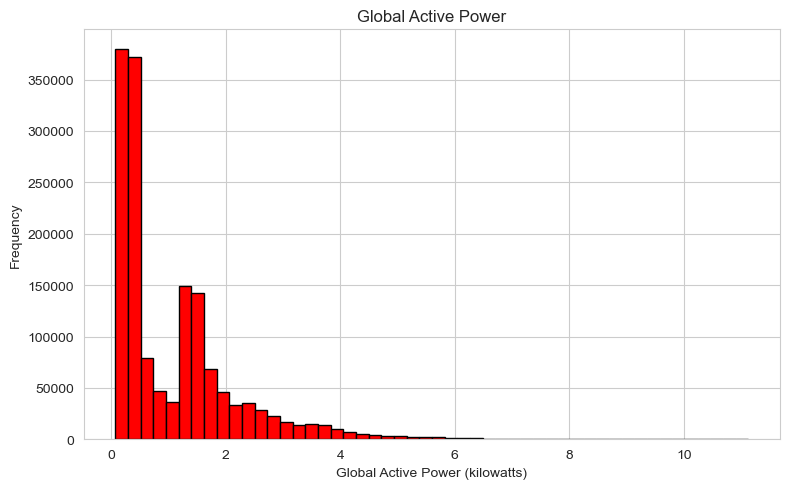

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(power['Global_active_power'], bins=50, color='red', edgecolor='black')
plt.xlabel('Global Active Power (kilowatts)')
plt.ylabel('Frequency')
plt.title('Global Active Power')
plt.tight_layout()
plt.show()

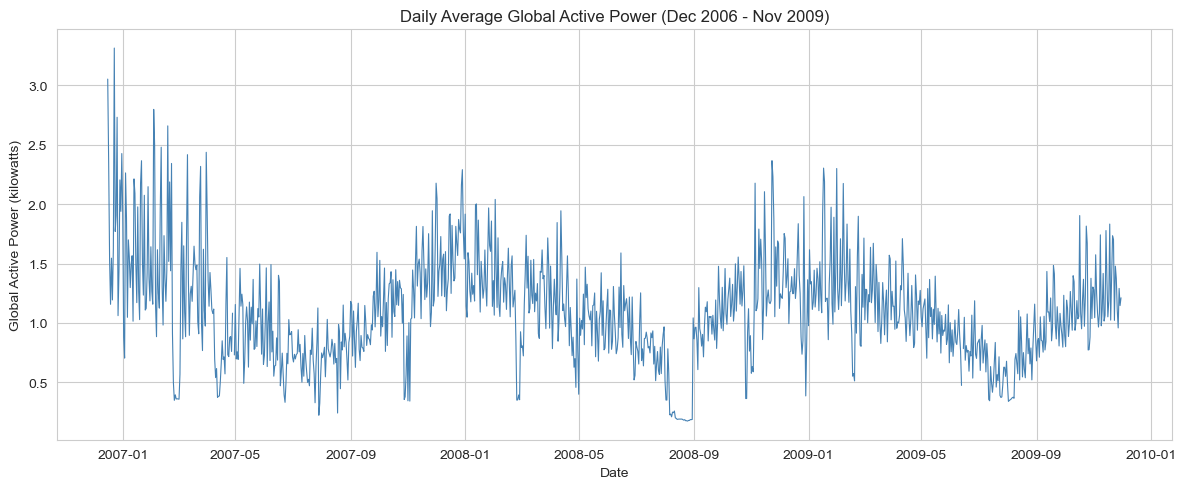

In [10]:
daily = power.resample('D').mean(numeric_only=True)
daily['month'] = daily.index.month
daily['month_name'] = daily.index.strftime('%b')
daily['year'] = daily.index.year
daily['weekday'] = daily.index.day_name()

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily['Global_active_power'], color='steelblue', linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Global Active Power (kilowatts)')
plt.title('Daily Average Global Active Power (Dec 2006 - Nov 2009)')
plt.tight_layout()
plt.show()

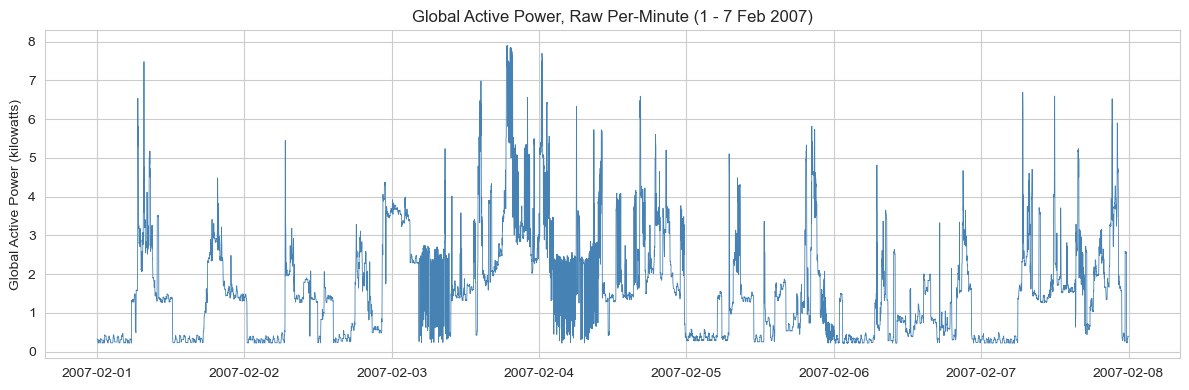

In [11]:
one_week = power.loc['2007-02-01':'2007-02-07']

plt.figure(figsize=(12, 4))
plt.plot(one_week.index, one_week['Global_active_power'], color='steelblue', linewidth=0.6)
plt.xlabel('')
plt.ylabel('Global Active Power (kilowatts)')
plt.title('Global Active Power, Raw Per-Minute (1 - 7 Feb 2007)')
plt.tight_layout()
plt.show()

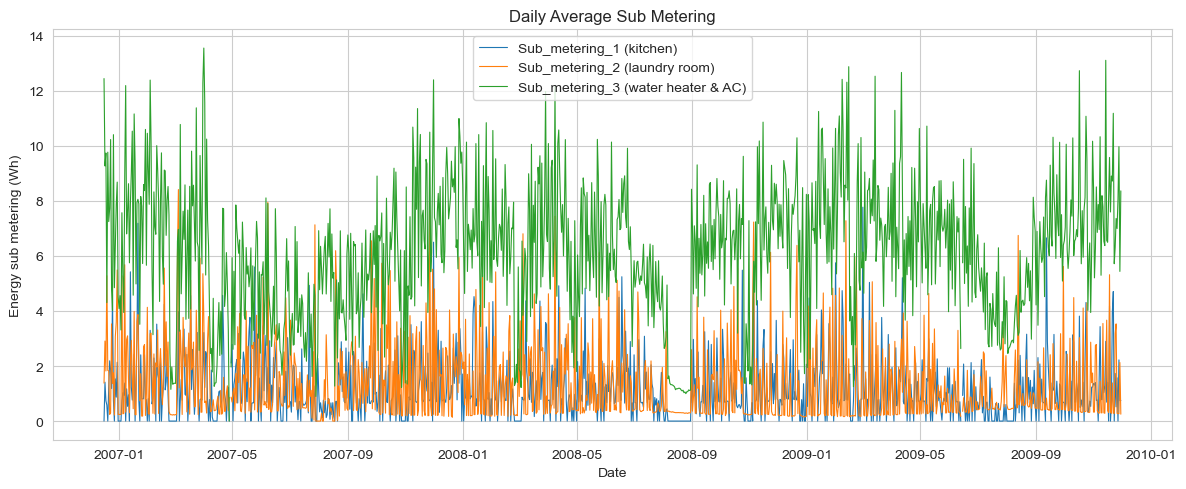

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily['Sub_metering_1'], label='Sub_metering_1 (kitchen)', linewidth=0.8)
plt.plot(daily.index, daily['Sub_metering_2'], label='Sub_metering_2 (laundry room)', linewidth=0.8)
plt.plot(daily.index, daily['Sub_metering_3'], label='Sub_metering_3 (water heater & AC)', linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Energy sub metering (Wh)')
plt.title('Daily Average Sub Metering')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
sample_df = power.sample(n=5000, random_state=1)

numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
                 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

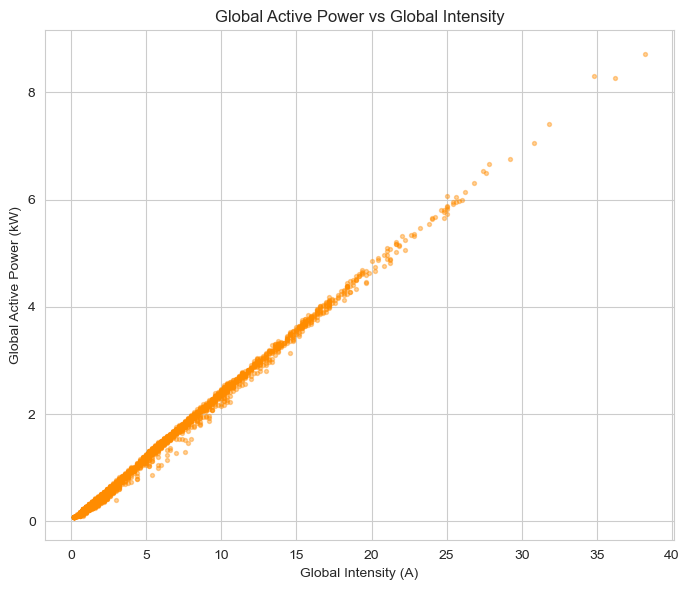

In [14]:
plt.figure(figsize=(7, 6))
plt.scatter(sample_df['Global_intensity'], sample_df['Global_active_power'],
            s=8, alpha=0.4, color='darkorange')
plt.xlabel('Global Intensity (A)')
plt.ylabel('Global Active Power (kW)')
plt.title('Global Active Power vs Global Intensity')
plt.tight_layout()
plt.show()

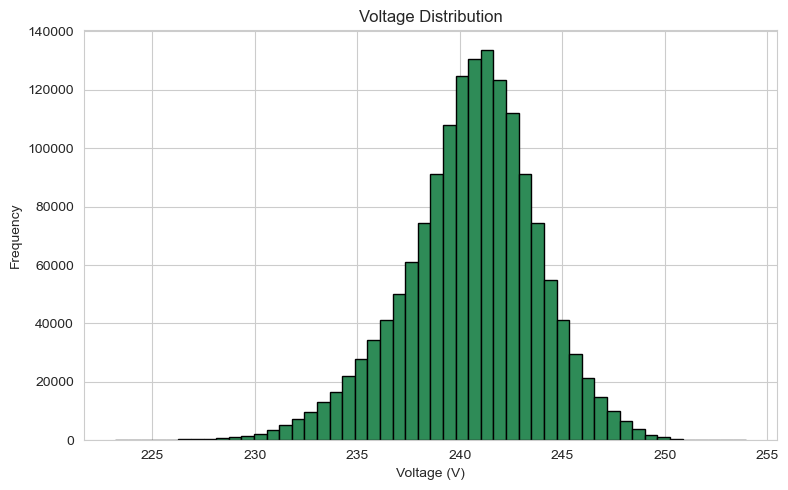

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(power['Voltage'], bins=50, color='seagreen', edgecolor='black')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequency')
plt.title('Voltage Distribution')
plt.tight_layout()
plt.show()

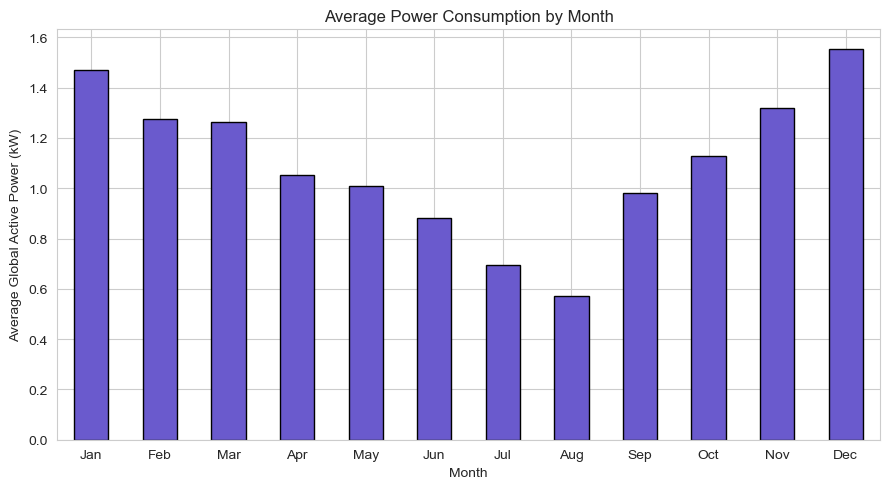

In [16]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = daily.groupby('month_name')['Global_active_power'].mean().reindex(month_order)

plt.figure(figsize=(9, 5))
monthly_avg.plot(kind='bar', color='slateblue', edgecolor='black')
plt.xlabel('Month')
plt.ylabel('Average Global Active Power (kW)')
plt.title('Average Power Consumption by Month')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

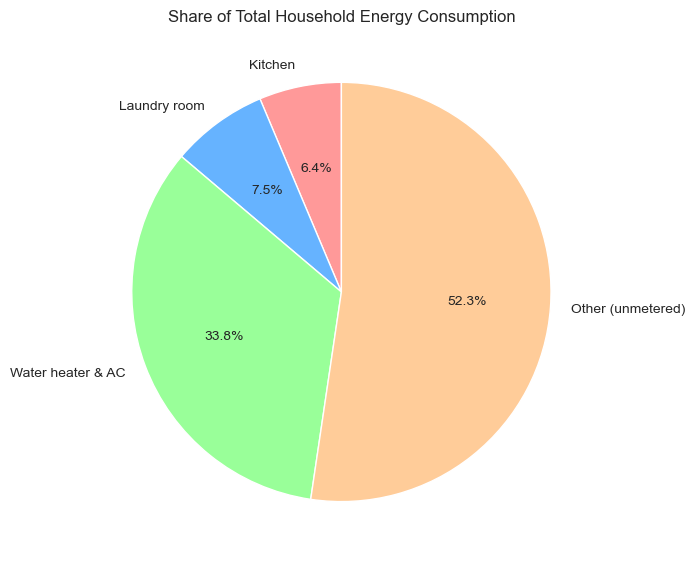

In [17]:
sm1 = power['Sub_metering_1'].sum()
sm2 = power['Sub_metering_2'].sum()
sm3 = power['Sub_metering_3'].sum()
total_wh = (power['Global_active_power'] * 1000 / 60).sum()
other = total_wh - (sm1 + sm2 + sm3)

plt.figure(figsize=(7, 7))
plt.pie([sm1, sm2, sm3, other],
        labels=['Kitchen', 'Laundry room', 'Water heater & AC', 'Other (unmetered)'],
        autopct='%1.1f%%', startangle=90,
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Share of Total Household Energy Consumption')
plt.tight_layout()
plt.show()

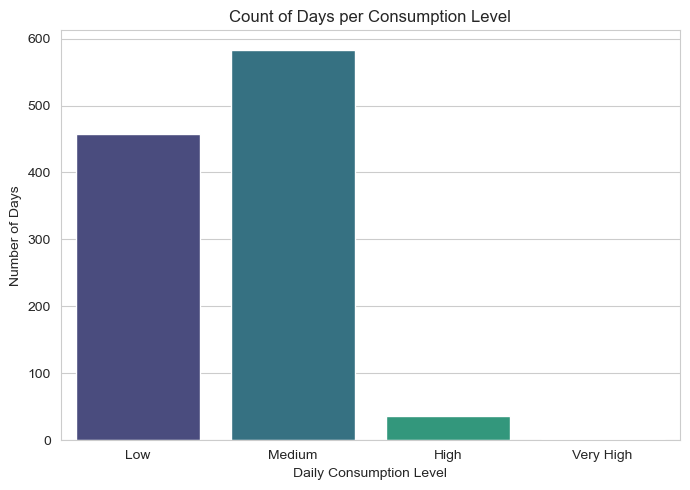

In [18]:
bins = [0, 1, 2, 3, 10]
labels = ['Low', 'Medium', 'High', 'Very High']
daily['consumption_level'] = pd.cut(daily['Global_active_power'], bins=bins, labels=labels)

plt.figure(figsize=(7, 5))
sns.countplot(x='consumption_level', data=daily, hue='consumption_level',
              palette='viridis', legend=False)
plt.xlabel('Daily Consumption Level')
plt.ylabel('Number of Days')
plt.title('Count of Days per Consumption Level')
plt.tight_layout()
plt.show()

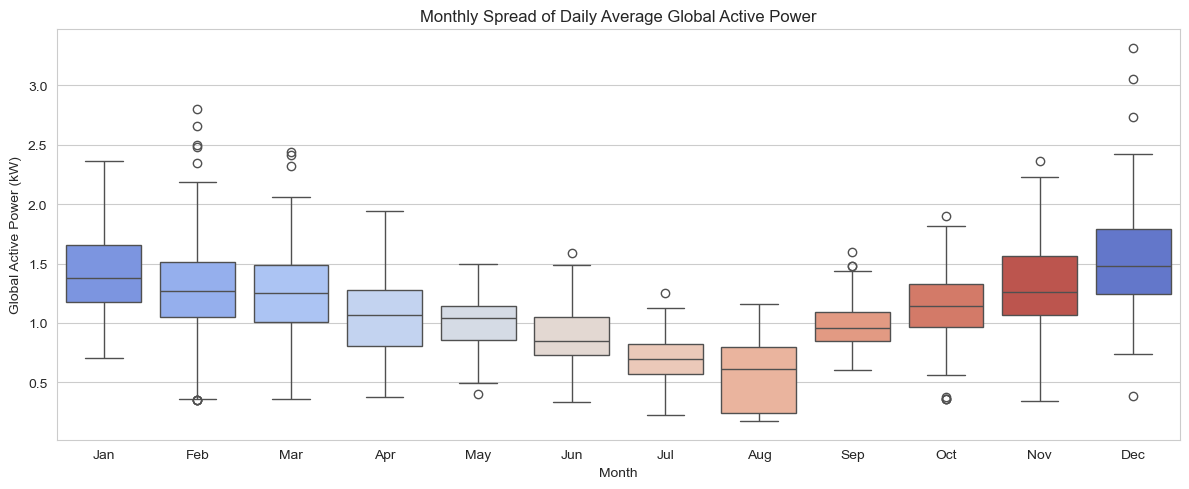

In [19]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='month_name', y='Global_active_power', data=daily, order=month_order,
            hue='month_name', palette='coolwarm', legend=False)
plt.xlabel('Month')
plt.ylabel('Global Active Power (kW)')
plt.title('Monthly Spread of Daily Average Global Active Power')
plt.tight_layout()
plt.show()

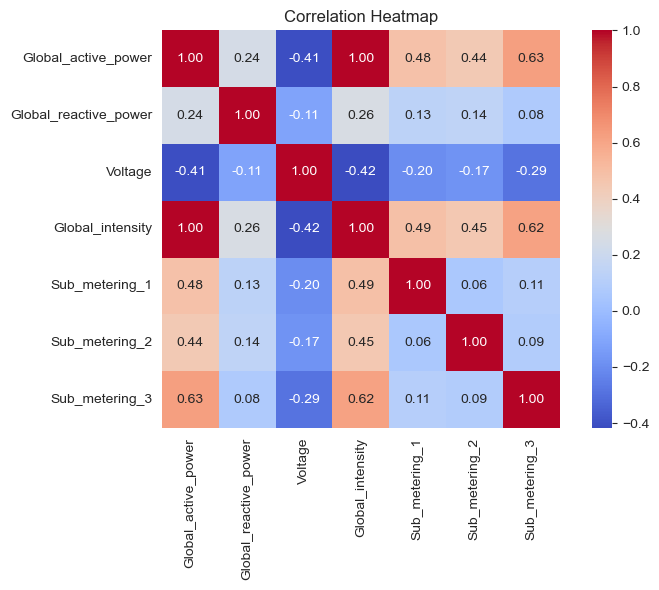

In [20]:
plt.figure(figsize=(8, 6))
corr = power[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

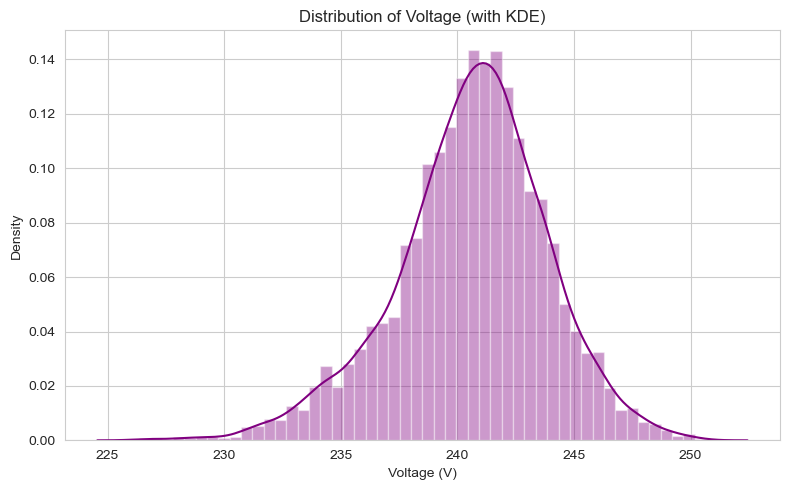

In [21]:
plt.figure(figsize=(8, 5))
sns.distplot(sample_df['Voltage'], color='purple')
plt.xlabel('Voltage (V)')
plt.title('Distribution of Voltage (with KDE)')
plt.tight_layout()
plt.show()

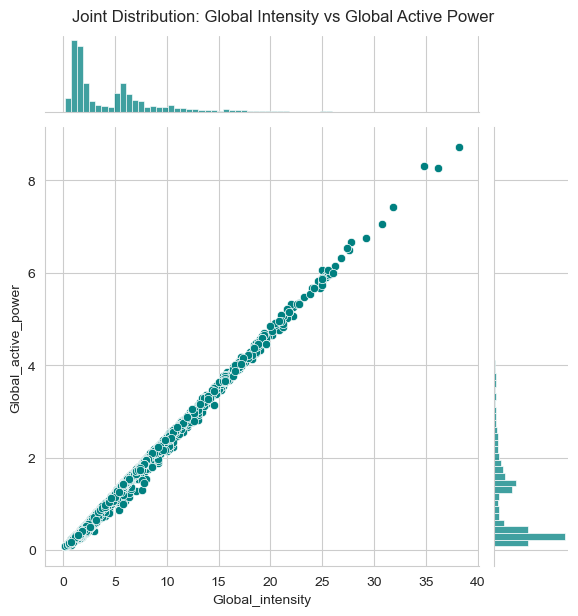

In [22]:
jp = sns.jointplot(x='Global_intensity', y='Global_active_power', data=sample_df,
                    kind='scatter', color='teal', height=6)
jp.fig.suptitle('Joint Distribution: Global Intensity vs Global Active Power', y=1.02)
plt.show()